In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
train_data = pd.read_csv(r"C:\Users\sidhu\OneDrive\Desktop\Kaggle\Titanic - Machine Learning from Disaster\data\train.csv")
train_data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
test_data = pd.read_csv(r"C:\Users\sidhu\OneDrive\Desktop\Kaggle\Titanic - Machine Learning from Disaster\data\test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
surviving_women = train_data.loc[train_data.Sex == "female"]["Survived"]
percent_of_women_alive = sum(surviving_women)/len(surviving_women) * 100

print("% of women alive: ", percent_of_women_alive)

% of women alive:  74.20382165605095


In [7]:
surviving_men = train_data.loc[train_data.Sex == "male"]["Survived"]
percent_of_men_alive = sum(surviving_men)/len(surviving_men) * 100

print("% of men alive: ", percent_of_men_alive)

% of men alive:  18.890814558058924


In [8]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survived  Deceased  Survived
Sex                         
female          81       233
male           468       109


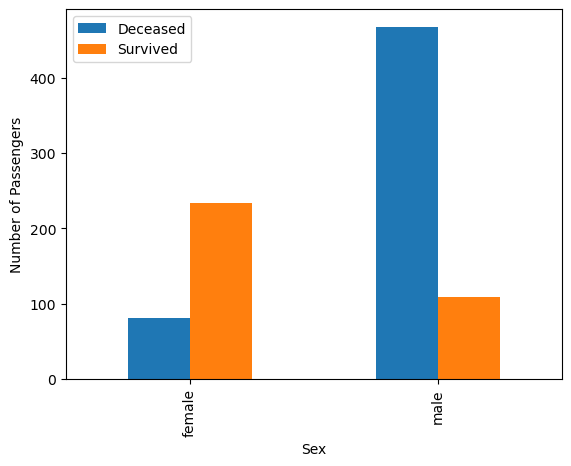

In [33]:
sex_survival = pd.crosstab(train_data["Sex"], train_data["Survived"].map({ 0 : "Deceased", 1 : "Survived"}))

print(sex_survival)

sex_survival.plot(kind = "bar")

plt.ylabel("Number of Passengers")
plt.legend(title = None)
plt.show()

Survived  Deceased  Survived
Age                         
0-10            26        38
10-20           71        44
20-30          146        84
30-40           86        69
40-50           53        33
50-60           25        17
60-70           13         4
70-80            4         1


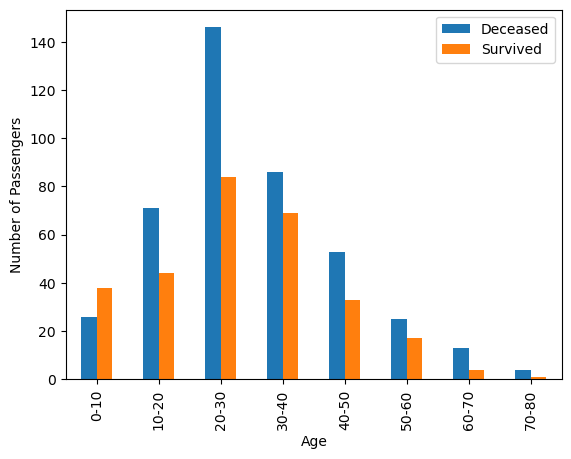

In [37]:
age_groups = pd.cut(train_data["Age"], 
                    bins = [0,10,20,30,40,50,60,70,80], 
                    labels = ["0-10", "10-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80"])

age_survival = pd.crosstab(age_groups, train_data["Survived"].map({ 0 : "Deceased", 1 : "Survived"}))

print(age_survival)

age_survival.plot(kind = "bar")

plt.ylabel("Number of Passengers")
plt.legend(title = None)
plt.show()



##### Perfect

Survived  Deceased  Survived
Pclass                      
1               80       136
2               97        87
3              372       119


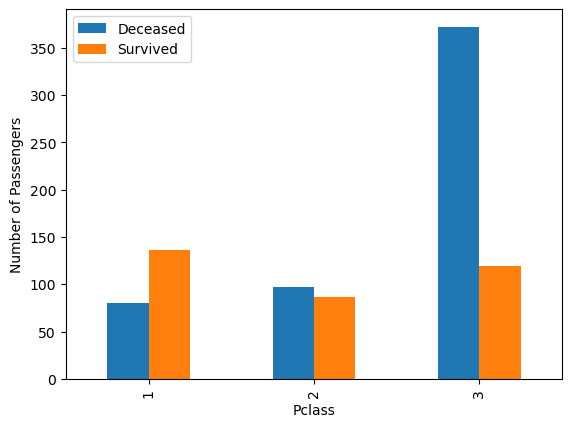

In [29]:
pclass_survival = pd.crosstab(train_data["Pclass"], train_data["Survived"].map({0: "Deceased", 1: "Survived"}))

print(pclass_survival)

pclass_survival.plot(kind = "bar")

plt.ylabel("Number of Passengers")
plt.legend(title = None)
plt.show()


Survived     Deceased  Survived
Embarked                       
Cherbourg          75        93
Queenstown         47        30
Southampton       427       217


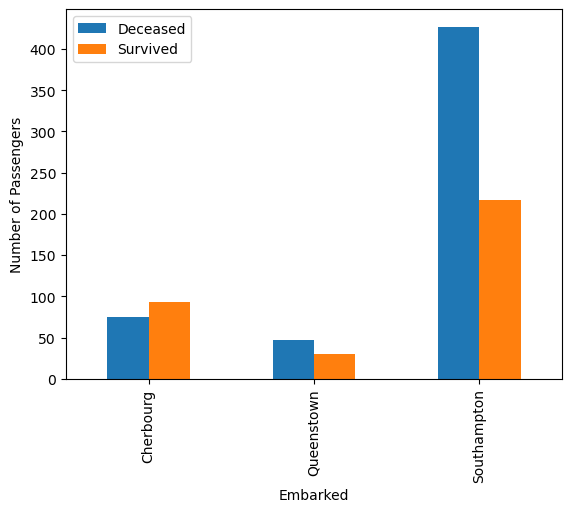

In [38]:
# train_data["Embarked"] = train_data["Embarked"].map({"C": "Cherbourg",
#                            "Q": "Queenstown",
#                            "S": "Southampton"})

# train_data["Survived"] = train_data["Survived"].map({0 : "Deceased", 1 : "Survived"})


# pd.crosstab(train_data["Embarked"], train_data["Survived"])

# Avoid writing the above during EDA if we only want to temporarily rename
# values for visualization or analysis. The assignment modifies the DataFrame
# in memory (not the original CSV file), which can cause problems if the
# operation is accidentally repeated.
# The assignment is perfectly valid when you intentionally want to modify the DataFrame.
# For all EDA purposes, write as below:

embarked_survival = pd.crosstab(
    train_data["Embarked"].map({"C": "Cherbourg",
                            "Q": "Queenstown",
                            "S": "Southampton"}) ,
train_data["Survived"].map({0 : "Deceased", 
                            1 : "Survived"}
            ))

print(embarked_survival)

embarked_survival.plot(kind = "bar")

plt.ylabel("Number of Passengers")
plt.legend(title = None)
plt.show()